# Simulated data
For this we will use simulated data instead of real data for the work.

In [15]:
import csv
import math
from datetime import datetime, timedelta
import random

# Setup parameters
start_time = datetime.now() - timedelta(days=2)     # Start 2 days ago
interval_minutes = 30                               # Sensor reading every 30 minutes, sparse enough
total_readings = int((48 * 60) / interval_minutes)  # 48 hours, 60 mins, 96 readings technically

base_temp = 20.0 # Average baseline temperature in Celsius
temp_variation = 8.0 # How much it fluctuates day/night

# Create temperature.csv
with open('temperature.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    # The notebook expects a Date and Temperature column
    writer.writerow(["date", "temperature"])

    for i in range(total_readings):
        current_time = start_time + timedelta(minutes=interval_minutes * i)

        # Use a sine wave to simulate natural day/night temperature curves
        # math.pi * 2 is a full day cycle.
        time_fraction = i / ( (24 * 60) / interval_minutes )
        fluctuation = math.sin(time_fraction * math.pi * 2) * temp_variation

        # Add a little random noise so it looks like a real, imperfect hardware sensor
        noise = random.uniform(-0.5, 0.5)

        simulated_temp = round(base_temp + fluctuation + noise, 2)

        # Format ISO timestamp
        writer.writerow([current_time.strftime("%Y-%m-%dT%H:%M:%S"), simulated_temp])

print("temperature.csv generated with 48 hours of simulated IoT data!")

temperature.csv generated with 48 hours of simulated IoT data!


# Growing Degree Days

This notebook loads temperature data saved in a CSV file, and analyzes it. It plots the temperatures, shows the highest and lowest value for each day, and calculates the GDD.

To use this notebook:

* Copy the `temperature.csv` file into the same folder as this notebook
* Run all the cells using the **▶︎ Run** button above. This will run the selected cell, then move to the next one.

In the cell below, set `base_temperature` to the base temperature of the plant.

In [16]:
base_temperature = 10

The CSV file now needs to be loaded, using pandas

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the temperature CSV file
df = pd.read_csv('temperature.csv')

The temperature can now be plotted on a graph.

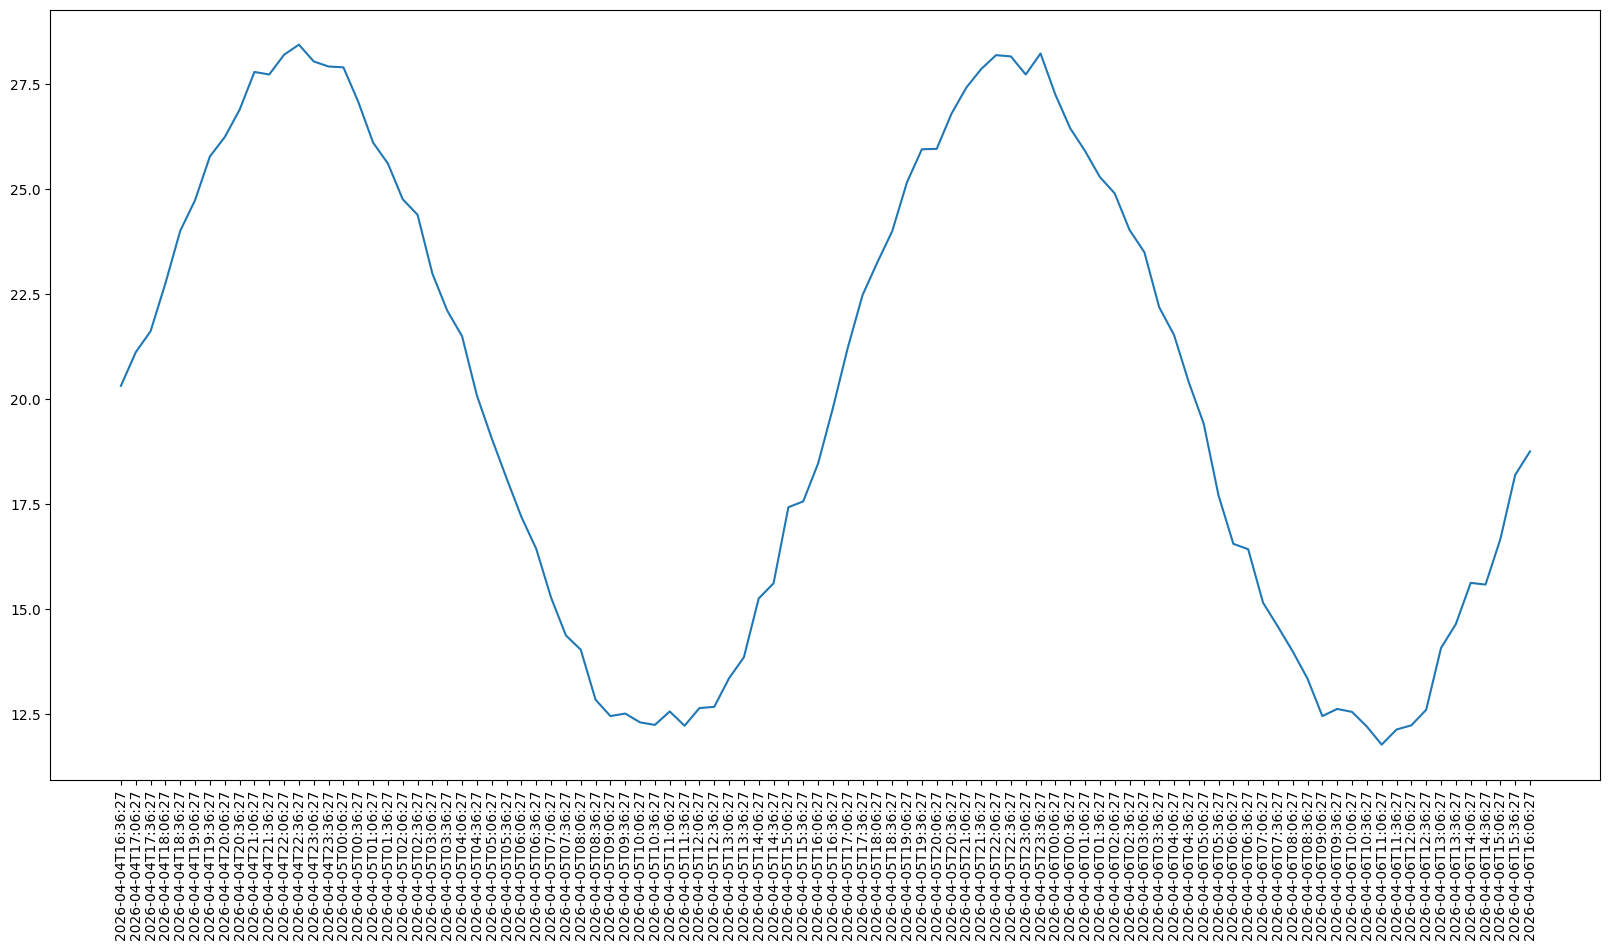

In [18]:
plt.figure(figsize=(20, 10))
plt.plot(df['date'], df['temperature'])
plt.xticks(rotation='vertical');

Once the data has been read it can be grouped by the `date` column, and the minimum and maximum temperatures extracted for each date.

In [19]:
# Convert datetimes to pure dates so we can group by the date
df['date'] = pd.to_datetime(df['date']).dt.date

# Group the data by date so it can be analyzed by date
data_by_date = df.groupby('date')

# Get the minimum and maximum temperatures for each date
min_by_date = data_by_date.min()
max_by_date = data_by_date.max()

# Join the min and max temperatures into one dataframe and flatten it
min_max_by_date = min_by_date.join(max_by_date, on='date', lsuffix='_min', rsuffix='_max')
min_max_by_date = min_max_by_date.reset_index()

The GDD can be calculated using the standard GDD equation

In [20]:
def calculate_gdd(row):
    return ((row['temperature_max'] + row['temperature_min']) / 2) - base_temperature

# Calculate the GDD for each row
min_max_by_date['gdd'] = min_max_by_date.apply (lambda row: calculate_gdd(row), axis=1)

# Print the results
print(min_max_by_date[['date', 'gdd']].to_string(index=False))

      date    gdd
2026-04-04 14.370
2026-04-05 10.220
2026-04-06  9.505
